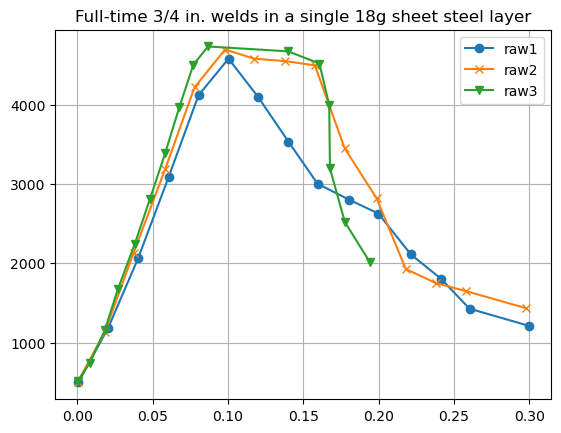

In [1]:
import math as m
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

raw1 = np.array([
    [0.0006801538746755709,  499.2319508448545],
    [0.02056509547645534,  1190.4761904761904],
    [0.04042222840192808,  2066.05222734255],
    [0.06063450129773823,  3087.557603686636],
    [0.08046846032628849,  4116.743471582182],
    [0.10038816277345197,  4577.572964669739],
    [0.1200732295142751,   4093.7019969278035],
    [0.1401470383759733,   3533.026113671275],
    [0.15946190211345943,  3003.072196620584],
    [0.18023556266221724,  2803.379416282642],
    [0.19987428160919543,  2626.7281105990783],
    [0.22144975899147204,  2112.1351766513058],
    [0.24148533092324806,  1804.9155145929344],
    [0.2603998655913978,   1428.571428571429],
    [0.2996564469781239,   1213.5176651305687]
], dtype=float)

raw2 = np.array([
    [0.0003018400074156491,  506.91244239631305],
    [0.018310275305895435, 1136.7127496159756],
    [0.037394558769002606, 2135.1766513056837],
    [0.058356507230255844, 3187.403993855607],
    [0.0778133110863923,   4216.589861751152],
    [0.09810785131627733,  4692.780337941629],
    [0.11736014553207266,  4577.572964669739],
    [0.1381083147942158,   4546.850998463902],
    [0.15772849462365593,  4493.087557603687],
    [0.17749814608824618,  3448.540706605223],
    [0.19871384872080086,  2818.740399385561],
    [0.21808317111605482,  1927.803379416283],
    [0.2380990452354468,   1751.1520737327187],
    [0.2577261772339636,   1651.305683563748],
    [0.2977370689655172,   1436.251920122888]
], dtype=float)

# #curve 3 
raw3 = np.array([
    [0.0003006813125695229,  514.5929339477734],
    [0.008186179087875431,   745.0076804915516],
    [0.018306799221357056,  1159.754224270353],
    [0.0269037356321839,    1674.347158218126],
    [0.03813264738598443,   2242.7035330261137],
    [0.048230093622543574,  2811.0599078341015],
    [0.05832638116425659,   3387.0967741935483],
    [0.06766835836114202,   3963.1336405529955],
    [0.07701612903225807,   4500.768049155146],
    [0.08678740266963295,   4731.1827956989255],
    [0.13997555153874677,   4669.738863287251],
    [0.16074225991842792,   4516.129032258064],
    [0.16723268909899888,   3993.855606758833],
    [0.16773034853540975,   3195.084485407066],
    [0.17763834816462734,   2519.201228878648],
    [0.19430964961067856,   2012.2887864823351]
], dtype=float)

x1= raw1[:,0]
y1 = raw1[:,1]
x2= raw2[:,0]
y2 = raw2[:,1]
x3= raw3[:,0]
y3 = raw3[:,1]
plt.figure()
plt.plot(x1,y1,marker='o',label="raw1")
plt.plot(x2,y2,marker='x',label="raw2")
plt.plot(x3,y3,marker='v',label="raw3")
plt.title("Full-time 3/4 in. welds in a single 18g sheet steel layer")
plt.grid(True)
plt.legend()
plt.show()

In [3]:
def support_group(n_col, n_row, col_spacing, row_spacing):
    x_support = []
    y_support = []
    for i in range(n_col):
        for j in range(n_row):
            x_support.append(i * col_spacing - (n_col - 1) * col_spacing / 2)
            y_support.append(j * row_spacing - (n_row - 1) * row_spacing / 2)
    return x_support, y_support

In [5]:
def force_from_curve(delta_i, delta_tab,force_tab, normalize_by = None):
    # castining deformations and force values into numpy arrays b/c NumPy arrays let us do fast, vectorized math
    delta_tab = np.asarray(delta_tab,dtype=float) 
    force_tab = np.asarray(force_tab,dtype=float)
    x = np.asarray(delta_tab, float)
    y = np.asarray(force_tab, float)

    #cliping delta values to the range using clipping If value < min_val, it gets replaced by min_val. Same is true the other way
    xi = np.clip(np.asarray(delta_i, float), x.min(), x.max()) #so if delta_i is < minimum deformation it is xmin (same for xmax), this is b/c We don’t want to interpolate outside the tabulated data range. 
    f = np.interp(xi, x, y)              # capped interpolation
    f = np.clip(f, 0.0, y.max())         # guard against tiny numeric overshoots, f < 0.0 → set it to 0., If f > y.max() → set it to y.max().
    if normalize_by is not None:
        f = np.clip(f / float(normalize_by), 0.0, 1.0) # we are making sure Makes sure normalized FORCE results are always between 0 and 1. We use this
        # if we normalize by pf_arc
    return f

In [7]:
def screw_force(delta_i, Ke, Ks, Kc, Kr, dy, dc, dr, df):
 # 1. Compute anchor forces at key points
    Fy = Ke * dy
    Fc = Fy + Ks * (dc - dy)
    Fr = Fc + Kc * (dr - dc)

    # 2. Piecewise definition
    if delta_i <= 0:
        return 0.0
    elif delta_i <= dy:   # elastic
        return Ke * delta_i
    elif delta_i <= dc:   # strain hardening
        return Fy + Ks * (delta_i - dy)
    elif delta_i <= dr:   # post-peak
        return Fc + Kc * (delta_i - dc)
    elif delta_i <= df:   # residual
        return max(0.0, Fr + Kr * (delta_i - dr))
    else:                 # beyond failure
        return 0.0

In [9]:
def ICM1(x_load, y_load, x_coord, y_coord, fastener_types, ArcDataLabel, screw_params,delta_max,lamda):
    x_centroid, y_centroid = np.mean(x_coord), np.mean(y_coord)
    n = len(x_coord)

    
    raw = curves[ArcDataLabel]
    delta_tab = raw[:, 0]
    force_tab = raw[:, 1] / 1000
    P_f_arc = max(raw[:, 1]) / 1000  # corrected (was raw1)
    

    Ke, Ks, Kc, Kr = screw_params['Ke'], screw_params['Ks'], screw_params['Kc'], screw_params['Kr']
    dy, dc, dr, df_screw = screw_params['dy'], screw_params['dc'], screw_params['dr'], screw_params['df']
    Fc = screw_params['Fc']  # peak force for normalization

    # ---------- LOAD SETUP ----------
    hori_angle = 0
    vert_angle = 90 - hori_angle
    Py, Px = (-1.0 * m.cos(vert_angle * (m.pi / 180)), m.sin(vert_angle * (m.pi / 180)))  # kips (Py < 0 means downward)
    Mo = Py * x_load - Px * y_load  # kip-in, moment about centroid

    # ---------- POLAR MOMENT ----------
    J = ((x_coord - x_centroid)**2 + (y_coord - y_centroid)**2).sum()
    
    # ---------- INITIAL ELASTIC IC GUESS ----------
    x_ic = x_centroid + (-Py * J) / (n * Mo)
    y_ic = y_centroid + (Px * J) / (n * Mo)

    # ---------- ITERATION PARAMETERS ----------
    threshold = 1e-3
    F = np.inf
    max_iter = 200
    eps = 1e-12  # for safe division

   # ---------- ITERATION LOOP ----------
    for it in range(max_iter):
        # Compute applied moment about current IC
        Mp = Py * (x_load - x_ic) - Px * (y_load - y_ic)

        # Build DataFrame for this iteration
        df = pd.DataFrame({
        'x_coordinate': x_coord, 'y_coordinate': y_coord, 'Fastener type': fastener_types}, index=[f"Fastener {i}" for i in range(1, n + 1)])
        df['dx'] = df['x_coordinate'] - x_ic
        df['dy'] = df['y_coordinate'] - y_ic
        df['d'] = np.sqrt(df['dx']**2 + df['dy']**2)

        
# Computing deformation component _______________________________________________
        df['ux'] = df['dx'] / (df['d'] + eps)
        df['uy'] = df['dy'] / (df['d'] + eps)

        # unit tangential direction (perpendicular to radial)
        df['tx'] = -df['uy']
        df['ty'] =  df['ux']

        # choose theta so that max slip magnitude equals delta_max
        theta = delta_max / (df['d'].max() + eps)

        # tangential slip vector components (this is the deformation direction in ICM)
        df['delta_x'] = theta * df['d'] * df['tx']
        df['delta_y'] = theta * df['d'] * df['ty']

        # slip magnitude (what you were using before)
        df['delta'] = np.hypot(df['delta_x'], df['delta_y'])

        def get_force_components(row):
            alpha_y = 0
            t = row['Fastener type']
        
            # normalized force ratio based on slip magnitude
            if t in ('InteriorArc', 'EndArc', 'EdgeArc'):
                r = force_from_curve(row['delta'], delta_tab, force_tab, normalize_by=P_f_arc)
            # apply efficiency
                if t == 'EndArc':
                    r *= lamda
                elif t == 'EdgeArc':
                    r *= lamda

            
            elif t == 'SideScrew':
                r = screw_force(row['delta'], Ke, Ks, Kc, Kr, dy, dc, dr, df_screw) / Fc
            else:
                raise ValueError(f"Unknown fastener type: {t}")
        
            # split that ratio into x/y components based on deformation direction
            # then weaken the y direction
            denom = (row['delta'] + eps)
            rx_ratio = r * (row['delta_x'] / denom)
            ry_ratio = r * (row['delta_y'] / denom) * alpha_y
        
            return pd.Series({'Rx_ratio': rx_ratio, 'Ry_ratio': ry_ratio})

        ratios = df.apply(get_force_components, axis=1)
        df = pd.concat([df, ratios], axis=1)

        df['R_ratio_mag'] = np.hypot(df['Rx_ratio'], df['Ry_ratio'])
        df['M'] = df['R_ratio_mag'] * df['d']
        sumMi = df['M'].sum()
        Rult = -Mp / (sumMi + eps)

        # Group ultimate scale factor
        Rult = -Mp / (sumMi + eps)
        Pult = sumMi / -Mp

        df['Rx'] = df['Rx_ratio'] * Rult
        df['Ry'] = df['Ry_ratio'] * Rult




        # Residual (unbalanced) forces
        Fxx = (Px + df['Rx'].sum())*1
        Fyy = (Py + df['Ry'].sum())*0
        F = np.hypot(Fxx, Fyy)

      # Optional: print convergence every 10 iterations
        if it % 10 == 0:
            print(f"Iter {it:3d} | F = {F:.6e} | IC = ({x_ic:.2f}, {y_ic:.2f})")

        # Convergence check
        if F < threshold:
            print(f"Converged at iteration {it}, F = {F:.4e}")
            break

        # Update IC location (Brandt's update rule)
        x_ic = x_ic - (Fyy * J) / (n * Mo)
        y_ic = y_ic + (Fxx * J) / (n * Mo)

    # ---------- OUTPUT ----------
    return df, Pult, Mp, sumMi,P_f_arc 

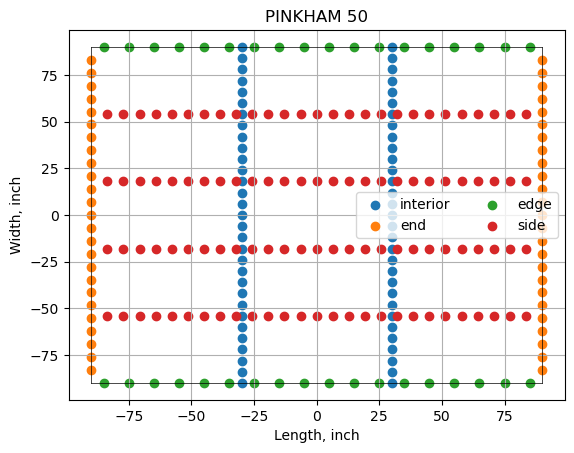

In [11]:
#Pinkham (1999) 50
interior_x, interior_y = support_group(2,31,5*12,6)
end_x,end_y = support_group(2,25,15*12,15*12/26)
edge_x, edge_y = support_group(18, 2, 10, 15*12)
side_x, side_y = support_group(27, 4, 15*12/28, 36)
plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label = 'end')
plt.scatter(edge_x, edge_y, label = 'edge')
plt.scatter(side_x, side_y , label = 'side')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.title('PINKHAM 50')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [53]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)



fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 40.37,      # kip/in
    'Ks': 1.65,
    'Kc': -1.48,
    'Kr': -1.48,
    'dy': 0.0314,     # in
    'dc': 0.145,
    'dr': 0.519,
    'df': 1.02,
    'Fc': 1.29        # kip (≈ F_c)
}

x_load, y_load = -90 , 90   # in
L = 15 
lamda =0.857 #directly from data sheet
lamda =1 #directly from data shee

delta_max = 0.30 #in #Used the max(screw,Arc) = Screw

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 1, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/6.19))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/5.17))

Iter   0 | F = 4.982242e-01 | IC = (-0.00, -69.37)
Iter  10 | F = 5.491547e-02 | IC = (-0.00, -47.41)
Iter  20 | F = 1.305068e-02 | IC = (-0.00, -45.88)
Iter  30 | F = 2.650988e-03 | IC = (-0.00, -45.50)
Converged at iteration 36, F = 9.9426e-04
Shear strength =  78.11 kips
Shear strength =   5.21 kips/ft
ICM/EXP = 0.84 
ICM/AISI = 1.01 
